In [78]:
import numpy as np
import xarray as xr
import wavespectra
from wavespectra import read_swan, read_era5, read_ndbc, read_netcdf, read_wwm
import cmocean
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import plotly.graph_objects as go
import numpy as np
from plotly.subplots import make_subplots
import inspect
from sklearn_extra.cluster import CLARA
from pysofar.sofar import SofarApi
from pysofar.spotter import Spotter
import hdpgpc.GPI_HDP as hdpgp
from hdpgpc.get_data import compute_estimators_LDS
from wavespectra.specdataset import SpecDataset
from wavespectra import specarray
import hdpgpc.GPI
import hdpgpc.GPI_model
from matplotlib import gridspec

import xarray as xr
from itertools import combinations
import numpy as np
import xarray as xr

import importlib
import pickle as plk

import torch

from wavespectra.partition import specpart
from wavespectra.core.utils import (
    set_spec_attributes,
    regrid_spec,
    smooth_spec,
    check_same_coordinates,
    D2R,
    celerity,
    is_overlap,
    waveage,
)

C:\Users\marco\anaconda3\envs\hdpgpc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [79]:
# Espectro de energía
ds_wave = xr.open_dataset("../data/NDBC/dir2017_dir.nc", decode_timedelta=True)

# Datos sobre el vientos
ds_meteo = xr.open_dataset("../data/NDBC/meteo2017.nc", decode_timedelta=True)

# Profundidad de medición
ds_ocean = xr.open_dataset("../data/NDBC/ocean2017.nc", decode_timedelta=True)

# Eliminar las dimensiones lat/lon (sólo hay un punto)
ds_meteo = ds_meteo.squeeze(["latitude", "longitude"])
ds_ocean = ds_ocean.squeeze(["latitude", "longitude"])

# Convertir variables codificadas a NumPy arrays para evitar problemas de interpolación
for ds in [ds_meteo, ds_ocean]:
    for var in ds.data_vars:
        ds[var].data = ds[var].values

# Interpolar viento y profundidad al tiempo del espectro
meteo_interp = ds_meteo.interp(time=ds_wave.time)

# Combinar todo en un nuevo dataset
ds = ds_wave.assign({
    "wspd": meteo_interp["wind_spd"],
    "wdir": meteo_interp["wind_dir"]
})

depth_value = float(ds_ocean["depth"].values[0])

dpt_da = xr.DataArray(
    data=np.full_like(ds.time, depth_value, dtype=np.float32),
    coords={"time": ds.time},
    dims=["time"],
    name="dpt"
)

ds["dpt"] = dpt_da

C:\Users\marco\AppData\Local\Temp\ipykernel_41960\573191810.py:17: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ms' instead. To silence this warning use time_unit='ms' in call to decoding function.

C:\Users\marco\AppData\Local\Temp\ipykernel_41960\573191810.py:17: SerializationWarning:

Can't decode floating point timedelta to 's' without precision loss, decoding to 'ns' instead. To silence this warning use time_unit='ns' in call to decoding function.



In [80]:
data = ds['efth'].to_numpy()
freq = ds['freq'].to_numpy()
dir = ds['dir'].to_numpy()

ds_n = read_ndbc('../data/NDBC/dir2017.nc', directional=False).isel(lat=0, lon=0)
data_no_direct = ds_n['efth'].to_numpy()

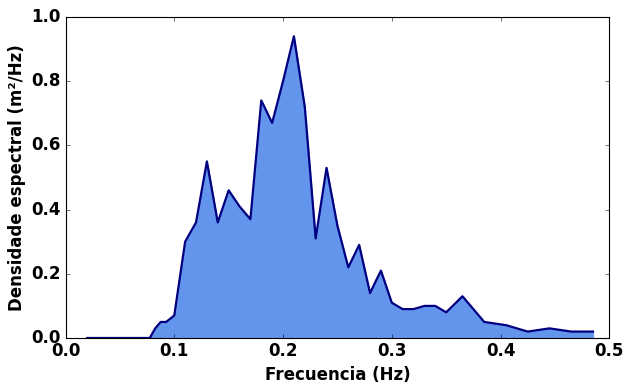

In [87]:
fig = plt.figure(figsize=(8,5))
plt.plot(freq, data_no_direct[123], color='navy', linewidth=2)
plt.fill_between(freq, data_no_direct[123], color='cornflowerblue', alpha=1)
plt.xlabel('Frecuencia (Hz)', fontsize=15, fontweight='bold')
plt.ylabel('Densidade espectral (m²/Hz)', fontsize=15, fontweight='bold')
plt.xticks(fontsize=15, fontweight='bold')
plt.yticks(fontsize=15, fontweight='bold')
plt.tight_layout()
fig.patch.set_alpha(0.0) 
plt.show()

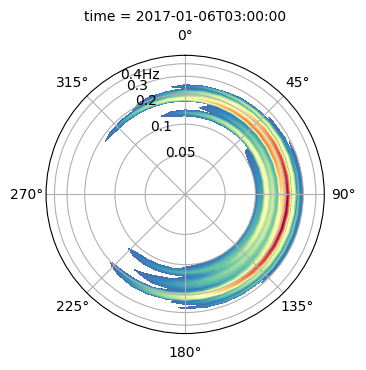

In [5]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt

# Colormap modificado: branco no mínimo
base_cmap = plt.get_cmap('Spectral_r')
colors = base_cmap(np.linspace(0.05, 1, 256))  # Cortamos a parte inferior
colors[0] = [1, 1, 1, 1]  # Branco no primeiro valor
custom_cmap = LinearSegmentedColormap.from_list("custom_spectral", colors)

ds2 = ds.isel(time=[123])
ds2.spec.plot(
    figsize = (4, 4),
    col="time",
    normalised=False,
    cmap=custom_cmap,
    
    add_colorbar=False,
    radii_labels_size=10, 
    radii_labels_angle=330, 
    levels=100
)

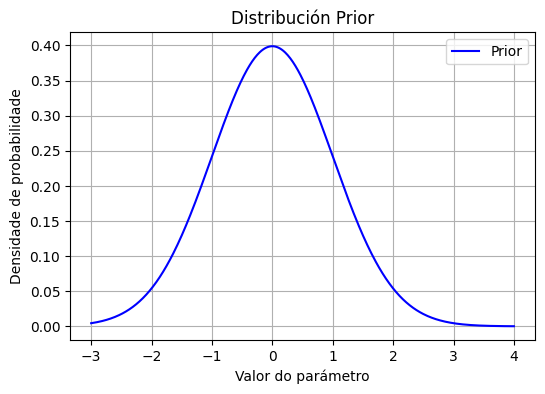

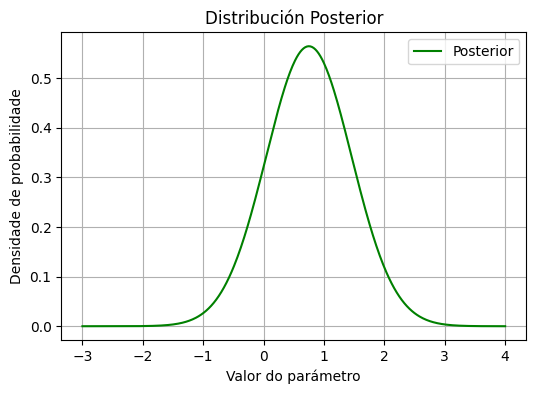

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Valores simulados para o exemplo
mu_prior = 0
sigma_prior = 1

mu_likelihood = 1.5
sigma_likelihood = 1

# Posterior simulada (supoñemos actualización bayesiana cunha normal conjugada)
sigma_post = 1 / np.sqrt(1/sigma_prior**2 + 1/sigma_likelihood**2)
mu_post = sigma_post**2 * (mu_prior/sigma_prior**2 + mu_likelihood/sigma_likelihood**2)

# Espazo de valores
x = np.linspace(-3, 4, 500)

# Gráfica do prior
plt.figure(figsize=(6, 4))
plt.plot(x, norm.pdf(x, mu_prior, sigma_prior), label="Prior", color='blue')
plt.title("Distribución Prior")
plt.xlabel("Valor do parámetro")
plt.ylabel("Densidade de probabilidade")
plt.grid(True)
plt.legend()
plt.show()

# Gráfica do posterior
plt.figure(figsize=(6, 4))
plt.plot(x, norm.pdf(x, mu_post, sigma_post), label="Posterior", color='green')
plt.title("Distribución Posterior")
plt.xlabel("Valor do parámetro")
plt.ylabel("Densidade de probabilidade")
plt.grid(True)
plt.legend()
plt.show()


In [3]:
import numpy as np

import xarray as xr

import matplotlib.pyplot as plt

import cmocean

from wavespectra import read_ww3, read_swan

from wavespectra.construct.frequency import pierson_moskowitz, jonswap, tma, gaussian

from wavespectra.construct.direction import cartwright, asymmetric

from wavespectra.construct import construct_partition, partition_and_reconstruct

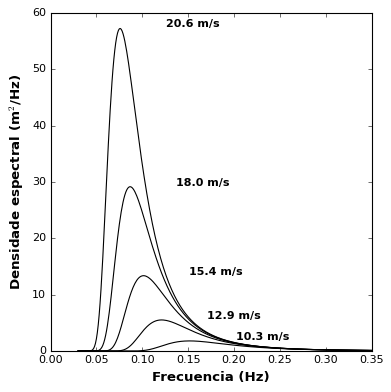

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import wavespectra as ws  # Asegúrate de que estás usando esta librería

# Estilo clásico e negro
plt.style.use('classic')
mpl.rcParams.update({
    "font.size": 10,
    "axes.labelweight": "normal",
    "axes.labelsize": 11,
    "axes.titlesize": 11,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.usetex": False,
    "lines.color": "black",
})

freq = np.arange(0.03, 0.351, 0.001)
dir = np.arange(0, 360, 1)

# Variar Hs ou fp para diferentes curvas
params = [
    (9, 0.05),
    (7, 0.07),
    (5, 0.09),
    (3, 0.11),
    (2, 0.13)
]

winds = [10.3, 12.9, 15.4, 18.0, 20.6]
g = 9.81

fig, ax = plt.subplots(figsize=(5, 5))

for w in winds:
    fp = g / (2 * np.pi * w)
    hs = 1.6 * w**2 / g  # fórmula típica Hs ≈ 0.21 * U10^2 / g
    
    dset = pierson_moskowitz(freq=freq, wind = w, fp=fp)
    ef = dset.spec.oned()
    ef.plot(ax=ax, color='black', linewidth=1)

    # Buscar pico para etiqueta
    f_peak = ef.freq[np.argmax(ef.values)]
    s_peak = ef.values.max()
    
    ax.text(
        f_peak + 0.05,
        s_peak + 0.2 ,
        f'{w:.1f} m/s',
        fontsize=10,
        fontweight='bold',
        ha='left'
    )

# Eixos e límites
ax.set_xlabel("Frecuencia (Hz)", fontsize=12, fontweight='bold')
ax.set_ylabel(r"Densidade espectral (m$^2$/Hz)", fontsize=12, fontweight='bold')
ax.grid(False)

fig.patch.set_alpha(0.0)   # fondo da figura
ax.patch.set_alpha(0.0)


plt.tight_layout()
plt.show()


0.25210084033613445
0.2142857142857143
0.17241379310344826
0.14705882352941177
0.11538461538461538


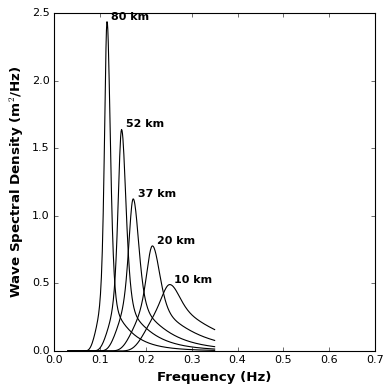

In [76]:
# Eixo de frecuencias
freq = np.arange(0.03, 0.351, 0.001)

# Distancias (km) e gammas asociados (máis distante → espectro máis agudo)
dist_gamma = {
    9.5: 1.5,
    20: 2.5,
    37: 3.3,
    52: 5.0,
    80: 7.0
}

# Crear figura
fig, ax = plt.subplots(figsize=(5, 5))

# Trazar curvas
for d, gamma in dist_gamma.items():
    fp = 0.3 / (1 + d / 50)  # fórmula empírica para desprazar o pico
    print(fp)
    dset = jonswap(freq=freq, fp=fp, hs=1.0, gamma=gamma)
    ef = dset.spec.oned().values

    ax.plot(freq, ef, color='black', linewidth=1)

    # Pico para poñer etiqueta
    idx_peak = np.argmax(ef)
    f_peak = freq[idx_peak]
    s_peak = ef[idx_peak]
    ax.text(
        f_peak + 0.01,
        s_peak + 0.015,
        f'{d:.0f} km',
        fontsize=10,
        fontweight='bold',
        ha='left'
    )

# Axustes dos eixos
ax.set_xlabel("Frequency (Hz)", fontsize=12, fontweight='bold')
ax.set_ylabel(r"Wave Spectral Density (m$^2$/Hz)", fontsize=12, fontweight='bold')
ax.set_xlim(0, 0.7)
ax.set_ylim(bottom=0)
ax.grid(False)

# Fondo transparente
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

plt.tight_layout()
plt.show()

In [33]:
dset = pierson_moskowitz(freq=freq, wind=10, fp=0.01)